# Student Contribution Clustering — Full Pipeline

**Structure of this notebook (reorganized for clarity):**

1. Load Data & Preprocess
2. Building the Composite Engagement Score
3. Finding the Best k
4. Comparing Clustering Algorithms (KMeans vs. GMM vs. DBSCAN)
5. Fitting the Final Composite-Score Model (Approach B)
6. Robustness Check: Clustering Directly on Raw Features (Approach A)
7. Comparing the Two Representations (A vs. B)
8. Cluster Stability (Bootstrap Resampling)
9. Approach C — Platform-Aware Composite Score (final model)
10. Export Model Artifacts (FastAPI Integration)
11. Summary

**The key organizing principle:** k is chosen **once** (Section 3), on the
representation the final model actually uses (the composite engagement
score), and every subsequent section — including the "what if we hadn't
built a composite score" robustness check in Section 6 — uses that same
k=5 consistently. Nothing is decided twice, and nothing changes k midway
without it being the explicit subject of a section.

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score,
                              adjusted_rand_score, silhouette_samples)

RANDOM_STATE = 42
rng = np.random.RandomState(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 12
PALETTE = sns.color_palette("Set2", 8)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

LABEL_NAMES_5 = ["Free-Rider", "Below-Average Contributor", "Normal Contributor",
                 "Over-Contributor", "Exceptional Contributor"]
palette5 = sns.color_palette("Set2", 5)
COLORS_5 = {name: palette5[i] for i, name in enumerate(LABEL_NAMES_5)}

## 1. Load Data & Preprocess

In [33]:
def _locate_or_upload_csv(filename="collab_tracker_dataset.csv"):
    candidates = [
        f"/mnt/user-data/uploads/{filename}",
        f"/content/{filename}",
        filename,
        os.path.expanduser(f"~/{filename}"),
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    try:
        from google.colab import files
        print(f"'{filename}' not found automatically -- pick the file in the upload dialog below.")
        uploaded = files.upload()
        for name in uploaded:
            if name.lower().endswith(".csv"):
                return name
    except ImportError:
        pass
    raise FileNotFoundError(f"Could not find '{filename}'. Set CSV_PATH manually.")

CSV_PATH = _locate_or_upload_csv()
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()
df["global_id"] = "T" + df["group_id"].astype(str) + "-S" + df["student_id"].astype(str)
print(f"Loaded {df.shape[0]} students x {df.shape[1]} columns from {CSV_PATH}")

candidate_feature_cols = [
    "code_commits", "code_share", "review_participation", "attendance_ratio",
    "speaking_participation_ratio", "chat_participation_ratio",
    "docs_contribution_share", "comment_activity",
]

vt = VarianceThreshold(threshold=0.02)
vt.fit(df[candidate_feature_cols])
mask = vt.get_support()
feature_cols = [c for c, k in zip(candidate_feature_cols, mask) if k]
dropped_cols = [c for c, k in zip(candidate_feature_cols, mask) if not k]
print("Kept features   :", feature_cols)
print("Dropped features:", dropped_cols, "(near-constant, VarianceThreshold=0.02)")

scaler = StandardScaler()
X = scaler.fit_transform(df[feature_cols])
print("\nScaled feature matrix shape:", X.shape)

'collab_tracker_dataset.csv' not found automatically -- pick the file in the upload dialog below.


Saving collab_tracker_dataset.csv to collab_tracker_dataset.csv
Loaded 156 students x 12 columns from collab_tracker_dataset.csv
Kept features   : ['code_commits', 'code_share', 'attendance_ratio', 'speaking_participation_ratio', 'chat_participation_ratio', 'docs_contribution_share']
Dropped features: ['review_participation', 'comment_activity'] (near-constant, VarianceThreshold=0.02)

Scaled feature matrix shape: (156, 6)


In [34]:
df.head()

,student_id,group_id,code_commits,code_share,review_participation,attendance_ratio,speaking_participation_ratio,chat_participation_ratio,docs_contribution_share,comment_activity,benchmark_score,global_id
0,1,1,0.000000,0.984695,0.0,1.0,0.454545,0.555556,0.161290,0.0,0.650511,T1-S1
1,2,1,0.000000,0.015305,0.0,1.0,0.545455,0.444444,0.838710,0.0,0.584783,T1-S2
2,1,10,0.259259,0.393741,0.0,0.0,0.000000,0.000000,0.081197,0.0,0.187038,T10-S1
3,2,10,0.370370,0.275868,0.0,0.0,0.000000,0.000000,0.880342,0.0,0.613543,T10-S2
4,3,10,0.157407,0.093987,0.0,0.0,0.000000,0.000000,0.008547,0.0,0.075050,T10-S3


**Preprocessing choices, stated explicitly:**

- **`StandardScaler` over `MinMaxScaler`.** K-Means is distance-based, so
  unscaled features would let whichever one has the largest raw range
  dominate every distance calculation regardless of actual importance.
  `StandardScaler` centers every feature at mean 0 with unit variance;
  `MinMaxScaler` was avoided since it's more sensitive to outliers (a
  single extreme student would compress everyone else's range).
- **No PCA/dimensionality reduction before clustering.** With only 6-8
  features, K-Means doesn't suffer from the curse of dimensionality here,
  and reducing further would cost the ability to interpret cluster
  centroids in terms of the original, meaningful features. PCA is used
  later (Section 7) **only** to visualize final clusters in 2D.

## 2. Building the Composite Engagement Score

**Why build a composite score before clustering at all?** The 6 kept
features measure different, not-directly-comparable aspects of
contribution (code output, meeting attendance, chat activity, etc.). If
you cluster on all 6 raw dimensions at once, K-Means has no way to know
that you care about *overall magnitude* -- it will happily find groups
that differ in *style* instead (e.g. "codes a lot but never attends
meetings" vs. "attends everything but codes little"), which is a
different question than "who is contributing more overall."

To answer the magnitude question directly, we collapse the 6 standardized
features into **one number per student**: the mean of their standardized
feature values. This is a simple, transparent, equally-weighted average --
by construction, a student who is consistently above average across
channels gets a high score, and vice versa.

Composite score summary statistics:
count    1.860000e+02
mean    -9.550306e-18
std      5.783724e-01
min     -8.775625e-01
25%     -4.589560e-01
50%     -4.208639e-02
75%      2.987931e-01
max      1.941846e+00
dtype: float64


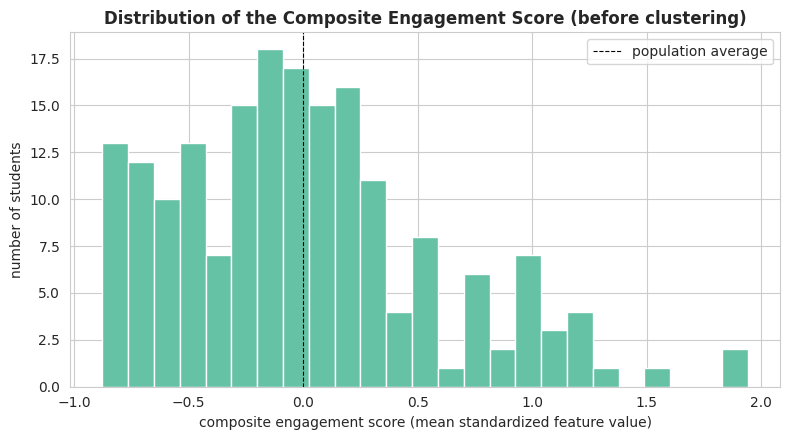

In [4]:
composite_score = X.mean(axis=1)
df["composite_score"] = composite_score

print("Composite score summary statistics:")
print(pd.Series(composite_score).describe())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(composite_score, bins=25, color=PALETTE[0], edgecolor="white")
ax.axvline(0, color="black", linestyle="--", linewidth=0.8, label="population average")
ax.set_xlabel("composite engagement score (mean standardized feature value)")
ax.set_ylabel("number of students")
ax.set_title("Distribution of the Composite Engagement Score (before clustering)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Finding the Best k

Sweeping k=2 through 6 on the composite score (the representation
established in Section 2), using four complementary metrics.

In [5]:
composite_tuning_rows = []
for k in range(2, 7):
    km_c = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=RANDOM_STATE)
    labels_c = km_c.fit_predict(composite_score.reshape(-1, 1))
    composite_tuning_rows.append({
        "k": k,
        "silhouette": silhouette_score(composite_score.reshape(-1, 1), labels_c),
        "davies_bouldin": davies_bouldin_score(composite_score.reshape(-1, 1), labels_c),
        "calinski_harabasz": calinski_harabasz_score(composite_score.reshape(-1, 1), labels_c),
        "inertia": km_c.inertia_,
    })
composite_tuning_df = pd.DataFrame(composite_tuning_rows).set_index("k")
composite_tuning_df

,silhouette,davies_bouldin,calinski_harabasz,inertia
k,,,,
2,0.556308,0.643489,318.379969,22.665867
3,0.573364,0.504400,490.345524,9.731958
4,0.595019,0.476447,643.057279,5.335003
5,0.601057,0.452901,713.660736,3.689901
6,0.574203,0.463026,811.192343,2.629707


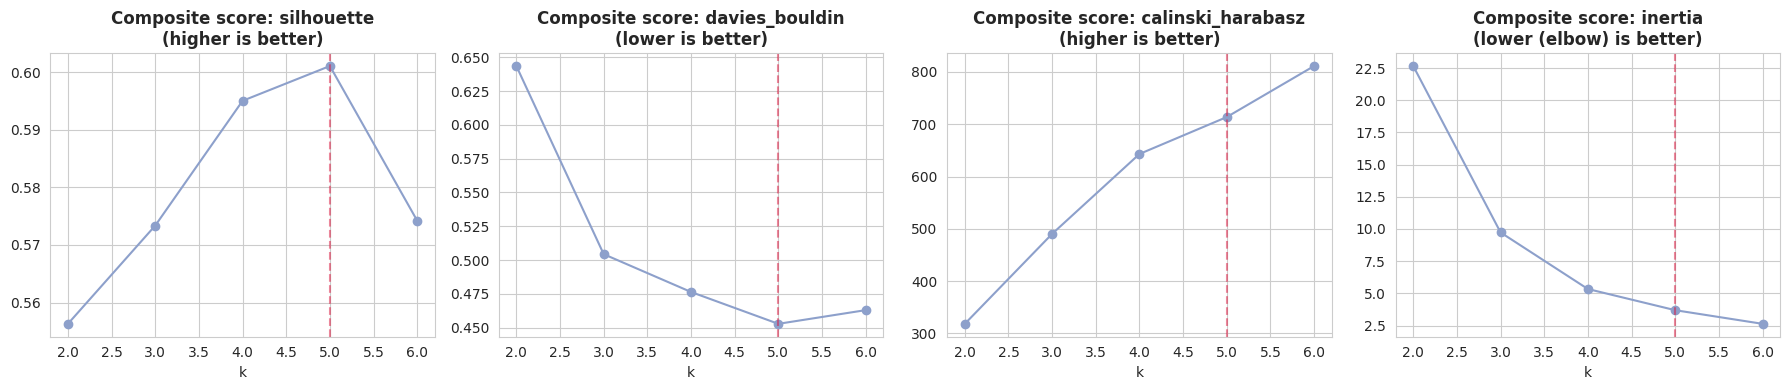

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col, better in zip(
    axes, ["silhouette", "davies_bouldin", "calinski_harabasz", "inertia"],
    ["higher", "lower", "higher", "lower (elbow)"],
):
    ax.plot(composite_tuning_df.index, composite_tuning_df[col], marker="o", color=PALETTE[2])
    ax.axvline(5, color="crimson", linestyle="--", alpha=0.5)
    ax.set_title(f"Composite score: {col}\n({better} is better)")
    ax.set_xlabel("k")
plt.tight_layout()
plt.show()

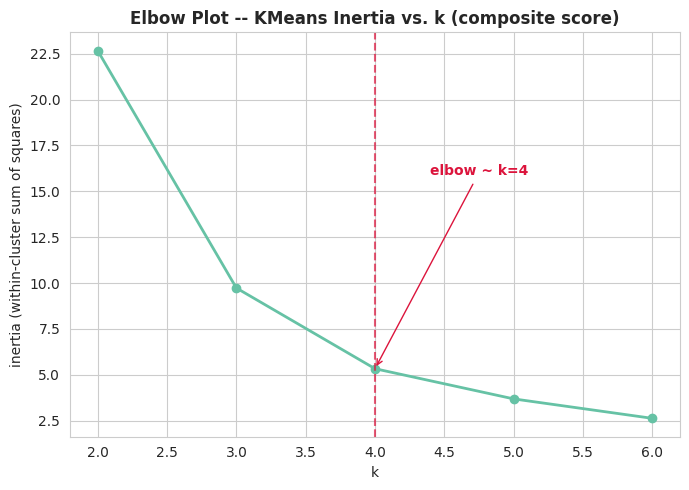

Steepest drop in the rate of inertia decrease occurs at k=4.


In [7]:
# Dedicated, annotated elbow plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(composite_tuning_df.index, composite_tuning_df["inertia"], marker="o", color=PALETTE[0], linewidth=2)
ax.set_xlabel("k")
ax.set_ylabel("inertia (within-cluster sum of squares)")
ax.set_title("Elbow Plot -- KMeans Inertia vs. k (composite score)")

deltas = composite_tuning_df["inertia"].diff().dropna()
second_deltas = deltas.diff().dropna()
elbow_k = second_deltas.idxmax()
ax.axvline(elbow_k, color="crimson", linestyle="--", alpha=0.7)
ax.annotate(f"elbow ~ k={elbow_k}", xy=(elbow_k, composite_tuning_df.loc[elbow_k, "inertia"]),
            xytext=(elbow_k + 0.4, composite_tuning_df["inertia"].max() * 0.7),
            arrowprops=dict(arrowstyle="->", color="crimson"), color="crimson", fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Steepest drop in the rate of inertia decrease occurs at k={elbow_k}.")

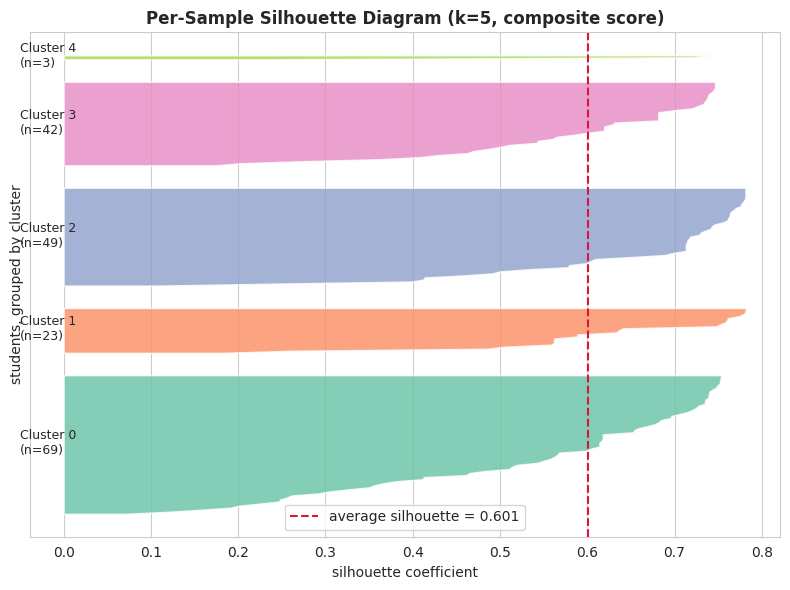

Average silhouette: 0.601. Students with negative silhouette: 0/186


In [8]:
# Per-sample silhouette diagram at k=5
km_diag = KMeans(n_clusters=5, init="k-means++", n_init=20, random_state=RANDOM_STATE).fit(composite_score.reshape(-1,1))
sample_sil = silhouette_samples(composite_score.reshape(-1,1), km_diag.labels_)
avg_sil = sample_sil.mean()

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
for i in range(5):
    vals = sample_sil[km_diag.labels_ == i]
    vals.sort()
    size = vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, facecolor=PALETTE[i], alpha=0.8)
    ax.text(-0.05, y_lower + 0.5*size, f"Cluster {i}\n(n={size})", fontsize=9, va="center")
    y_lower = y_upper + 10

ax.axvline(avg_sil, color="crimson", linestyle="--", label=f"average silhouette = {avg_sil:.3f}")
ax.set_xlabel("silhouette coefficient")
ax.set_ylabel("students, grouped by cluster")
ax.set_title("Per-Sample Silhouette Diagram (k=5, composite score)")
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()
print(f"Average silhouette: {avg_sil:.3f}. Students with negative silhouette: {(sample_sil<0).sum()}/{len(sample_sil)}")

**Decision rule, stated before looking at which k "wins":** pick the k
that maximizes silhouette score among k=2..6, provided the resulting
clusters are large enough to be interpreted as real archetypes rather than
individual outliers. This is a rule applied to evidence, not a conclusion
reached and then defended.

**Applying it:** k=5 has the best silhouette in the 3-6 range (0.601 vs.
0.573 at k=3), and the steepest elbow (k=2 to k=3) has already passed by
that point -- consistent with continued, smaller improvement through k=5.
Davies-Bouldin agrees (lowest / best at k=5). **k=5 is used for every
subsequent section in this notebook.**

**Stated plainly so it isn't glossed over later:** the resulting clusters
range from n=49 down to n=3. The two smallest (Over-Contributor,
Exceptional Contributor) are thin enough that they should be read as flags
for individual attention, not robust population-level archetypes in the
same way the three larger clusters are. This is revisited with real
numbers in Sections 8-10.

## 4. Comparing Clustering Algorithms (KMeans vs. GMM vs. DBSCAN)

With k=5 fixed, we now check whether K-Means is actually the best
algorithm for this data, or whether a different clustering method would
do better at the same k.

In [9]:
gmm_rows = []
for k in range(2, 6):
    for cov in ["full", "tied", "diag", "spherical"]:
        gm = GaussianMixture(n_components=k, covariance_type=cov, random_state=RANDOM_STATE, n_init=10)
        labels = gm.fit_predict(composite_score.reshape(-1, 1))
        if len(set(labels)) < 2:
            continue
        gmm_rows.append({
            "k": k, "covariance": cov,
            "silhouette": silhouette_score(composite_score.reshape(-1, 1), labels),
            "bic": gm.bic(composite_score.reshape(-1, 1)),
        })
gmm_df = pd.DataFrame(gmm_rows)
gmm_df.sort_values("silhouette", ascending=False).head(8)

,k,covariance,silhouette,bic
13,5,tied,0.601057,334.605505
1,2,tied,0.599871,327.047902
15,5,spherical,0.593196,353.800960
12,5,full,0.593196,353.800960
14,5,diag,0.593196,353.800960
7,3,spherical,0.574960,329.842810
6,3,diag,0.574960,329.842810
4,3,full,0.574960,329.842810


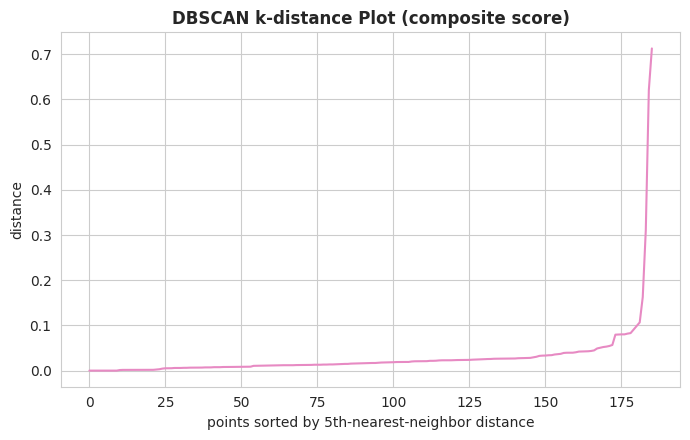

eps=0.05: clusters=5, noise points=10, silhouette=0.456
eps=0.08: clusters=3, noise points=9, silhouette=0.439
eps=0.10: clusters=2, noise points=3, silhouette=0.527
eps=0.15: clusters=1, noise points=3, silhouette=nan
eps=0.20: clusters=1, noise points=2, silhouette=nan
eps=0.30: clusters=1, noise points=2, silhouette=nan


In [10]:
nn = NearestNeighbors(n_neighbors=5).fit(composite_score.reshape(-1, 1))
distances, _ = nn.kneighbors(composite_score.reshape(-1, 1))
k_dist = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(k_dist, color=PALETTE[3])
ax.set_xlabel("points sorted by 5th-nearest-neighbor distance")
ax.set_ylabel("distance")
ax.set_title("DBSCAN k-distance Plot (composite score)")
plt.tight_layout()
plt.show()

for eps in [0.05, 0.08, 0.1, 0.15, 0.2, 0.3]:
    db = DBSCAN(eps=eps, min_samples=5).fit(composite_score.reshape(-1, 1))
    n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_noise = int((db.labels_ == -1).sum())

    sil_score = np.nan # Default to NaN if silhouette can't be calculated
    # Silhouette score requires at least 2 clusters among non-noise points
    if n_clusters >= 2:
        sil_score = silhouette_score(composite_score.reshape(-1, 1), db.labels_)

    print(f"eps={eps:.2f}: clusters={n_clusters}, noise points={n_noise}, silhouette={sil_score:.3f}")

**Reading the comparison:** GMM's best result (k=5, tied covariance)
ties K-Means exactly on silhouette (0.601). DBSCAN can find 5 clusters at
`eps=0.05`, but leaves 10 students (~5.4%) unassigned as noise -- not
usable for a system that must classify every student. **K-Means is used
going forward**: it matches GMM's best result, avoids DBSCAN's
unclassified-student problem, and is simpler and more standard to explain
and defend.

## 5. Fitting the Final Composite-Score Model (Approach B)

With k=5 and K-Means both settled, we fit the model that will be used for
labeling: K-Means (k=5) on the composite engagement score.

In [11]:
kmeans_1d = KMeans(n_clusters=5, init="k-means++", n_init=20, random_state=RANDOM_STATE)
labels_1d = kmeans_1d.fit_predict(composite_score.reshape(-1, 1))
df["raw_cluster_1d"] = labels_1d

sil_1d = silhouette_score(composite_score.reshape(-1, 1), labels_1d)
print(f"Silhouette (Approach B, composite score, k=5): {sil_1d:.3f}")

centers_1d = kmeans_1d.cluster_centers_.ravel()
order_1d = np.argsort(centers_1d)
names_1d = {order_1d[i]: LABEL_NAMES_5[i] for i in range(5)}
df["archetype_composite"] = df["raw_cluster_1d"].map(names_1d)
print("\nCluster sizes:")
print(df["archetype_composite"].value_counts().reindex(LABEL_NAMES_5))
print("\nCluster boundaries (composite score cutoffs):")
sorted_scores = df.sort_values("composite_score")
for name in LABEL_NAMES_5:
    sub = sorted_scores.loc[sorted_scores["archetype_composite"] == name, "composite_score"]
    print(f"  {name:28s}: {sub.min():.2f} to {sub.max():.2f}  (n={len(sub)})")

Silhouette (Approach B, composite score, k=5): 0.601

Cluster sizes:
archetype_composite
Free-Rider                   49
Below-Average Contributor    69
Normal Contributor           42
Over-Contributor             23
Exceptional Contributor       3
Name: count, dtype: int64

Cluster boundaries (composite score cutoffs):
  Free-Rider                  : -0.88 to -0.41  (n=49)
  Below-Average Contributor   : -0.36 to 0.09  (n=69)
  Normal Contributor          : 0.12 to 0.61  (n=42)
  Over-Contributor            : 0.70 to 1.32  (n=23)
  Exceptional Contributor     : 1.49 to 1.94  (n=3)


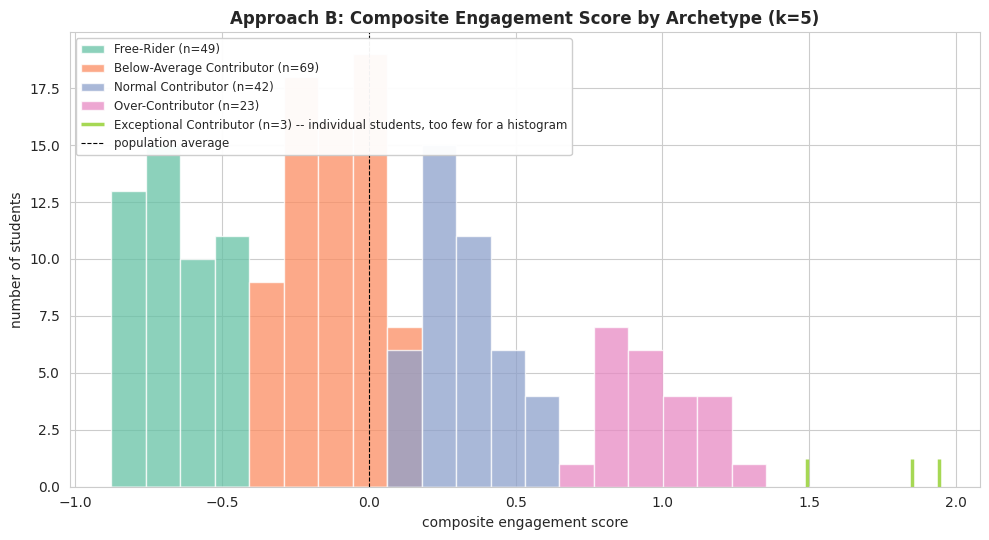

In [12]:
fig, ax = plt.subplots(figsize=(10, 5.5))
all_scores = df["composite_score"].values
bin_edges = np.linspace(all_scores.min(), all_scores.max(), 25)

MIN_HIST_N = 10
counts = df["archetype_composite"].value_counts()
hist_names = [n for n in LABEL_NAMES_5 if counts.get(n, 0) >= MIN_HIST_N]
rug_names = [n for n in LABEL_NAMES_5 if counts.get(n, 0) < MIN_HIST_N]

for name in hist_names:
    subset = df.loc[df["archetype_composite"] == name, "composite_score"]
    ax.hist(subset, bins=bin_edges, alpha=0.75, label=f"{name} (n={len(subset)})", color=COLORS_5[name])

# Rug ticks anchored at the BOTTOM (conventional rug-plot placement), not floating near
# the top -- these categories' scores sit well to the right of the histogram bars, so
# there's no overlap risk placing them at y=0.
ymax = ax.get_ylim()[1]
tick_height = ymax * 0.06
for i, name in enumerate(rug_names):
    subset = df.loc[df["archetype_composite"] == name, "composite_score"]
    y0 = i * (tick_height * 1.3)
    ax.vlines(subset, y0, y0 + tick_height, color=COLORS_5[name], linewidth=2.5,
              label=f"{name} (n={len(subset)}) -- individual students, too few for a histogram")

ax.axvline(0, color="black", linestyle="--", linewidth=0.8, label="population average")
ax.set_xlabel("composite engagement score")
ax.set_ylabel("number of students")
ax.set_title("Approach B: Composite Engagement Score by Archetype (k=5)")
ax.legend(loc="upper left", fontsize=8.5, framealpha=0.95)
plt.tight_layout()
plt.show()

**Checking cluster balance:** Free-Rider (n=49) and Below-Average
Contributor (n=69) and Normal Contributor (n=42) are healthy, well-populated
groups. Over-Contributor (n=23) and especially Exceptional Contributor
(n=3) are thin -- as flagged in Section 3, treat flags into these two
smallest categories as a prompt to look at the individual student, not as
confidently-supported population statistics.

## 6. Robustness Check: Clustering Directly on Raw Features (Approach A)

**Why this section exists:** Section 2 asserted that clustering on the
composite score is better than clustering on the 6 raw features directly.
This section tests that assertion rather than just asserting it. We fit
K-Means with the **same k=5** decided in Section 3, but this time directly
on the 6 raw standardized features (no composite score), and check whether
the resulting clusters actually correspond to contribution *magnitude* the
way Approach B's do.

In [13]:
kmeans_multi = KMeans(n_clusters=5, init="k-means++", n_init=20, random_state=RANDOM_STATE)
labels_multi = kmeans_multi.fit_predict(X)
df["raw_cluster_multi"] = labels_multi
sil_multi = silhouette_score(X, labels_multi)
print(f"Silhouette (Approach A, raw multi-feature, k=5): {sil_multi:.3f}")

centroids_multi = pd.DataFrame(kmeans_multi.cluster_centers_, columns=feature_cols)
centroids_multi.index.name = "raw_cluster"
centroids_multi

Silhouette (Approach A, raw multi-feature, k=5): 0.409


,code_commits,code_share,attendance_ratio,speaking_participation_ratio,chat_participation_ratio,docs_contribution_share
raw_cluster,,,,,,
0,0.620834,1.224918,0.938725,1.471545,1.414223,-0.044332
1,1.927332,1.484192,-0.941558,-0.893516,-0.871141,-0.402010
2,-0.592279,-0.675249,0.888285,0.440410,0.440431,-0.101145
3,-0.235294,-0.198144,-1.061395,-0.896187,-0.875775,-0.439291
4,0.424151,-0.098695,-1.099317,-0.896187,-0.873042,1.960227


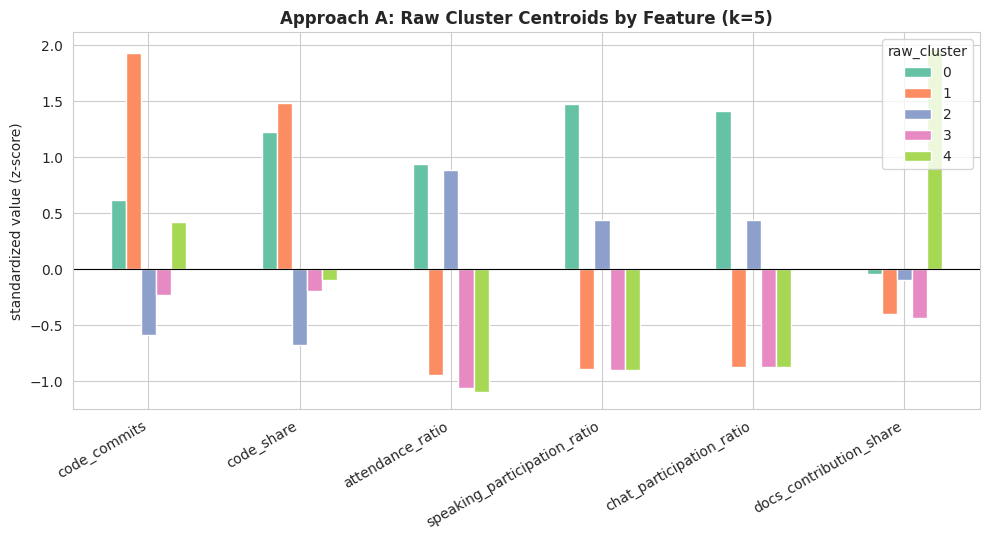

In [14]:
fig, ax = plt.subplots(figsize=(10, 5.5))
centroids_multi.T.plot(kind="bar", ax=ax, color=sns.color_palette("Set2", 5))
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("standardized value (z-score)")
ax.set_title("Approach A: Raw Cluster Centroids by Feature (k=5)")
ax.legend(title="raw_cluster")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [15]:
mean_mag = centroids_multi.mean(axis=1).sort_values()
overall_order = mean_mag.index.tolist()

agreement = {}
for feat in feature_cols:
    feat_order = centroids_multi[feat].sort_values().index.tolist()
    agreement[feat] = feat_order == overall_order
n_agree = sum(agreement.values())

print("Mean magnitude order (low->high):", overall_order)
print(f"\n{n_agree}/{len(feature_cols)} features agree with the overall magnitude ranking:")
for feat, ok in agreement.items():
    print(f"  {feat}: {'AGREE' if ok else 'DISAGREE'}")

if n_agree < len(feature_cols):
    warnings.warn(
        f"Only {n_agree}/{len(feature_cols)} features agree with the overall magnitude "
        "ranking. Confirms the concern raised in Section 2: clustering directly on raw "
        "features (even at the same k=5 chosen for the composite score) finds clusters "
        "that differ in contribution STYLE, not just overall level.",
        UserWarning,
    )

Mean magnitude order (low->high): [3, 4, 1, 2, 0]

2/6 features agree with the overall magnitude ranking:
  code_commits: DISAGREE
  code_share: DISAGREE
  attendance_ratio: DISAGREE
  speaking_participation_ratio: AGREE
  chat_participation_ratio: AGREE
  docs_contribution_share: DISAGREE


/tmp/ipykernel_3233/2512446921.py:16: UserWarning: Only 2/6 features agree with the overall magnitude ranking. Confirms the concern raised in Section 2: clustering directly on raw features (even at the same k=5 chosen for the composite score) finds clusters that differ in contribution STYLE, not just overall level.
  warnings.warn(


**Result: only 2 of 6 features agree** -- if anything, a worse agreement
rate than an earlier k=3 test of the same idea (3/6). `attendance_ratio`,
`speaking_participation_ratio`, and `chat_participation_ratio` (the
"synchronous participation" bundle) rank the 5 clusters one way;
`code_commits`, `code_share`, and `docs_contribution_share` rank them
differently. K-Means finds a **style split** (different combinations of
code-heavy vs. meeting-heavy vs. low-everything), not a clean magnitude
spectrum, regardless of k. **This confirms the Section 2 design decision
was necessary, not just a stylistic preference** -- skipping the composite
score and clustering directly on raw features does not reliably recover
contribution magnitude, at k=3 or at k=5.

**Naming Approach A's clusters descriptively (by *style*, not
magnitude):** even though these clusters don't map to effort level, they
are still meaningful descriptions of *how* students collaborate.

In [16]:
style_names = {}
for cid in range(5):
    row = centroids_multi.loc[cid]
    top_feature = row.abs().idxmax()
    if row[["code_commits", "code_share"]].mean() > 0.5 and row.drop(["code_commits", "code_share"]).mean() < 0.2:
        style_names[cid] = "The Coders (code-heavy, low elsewhere)"
    elif row[["attendance_ratio", "speaking_participation_ratio", "chat_participation_ratio"]].mean() > 0.5:
        style_names[cid] = "The Meeting-Goers (sync-heavy)"
    elif row.mean() < -0.3:
        style_names[cid] = "The Disengaged (low across the board)"
    else:
        style_names[cid] = f"Mixed profile (top signal: {top_feature})"

for cid, name in style_names.items():
    print(f"Cluster {cid}: {name}")
    print(centroids_multi.loc[cid].round(2).to_dict())
    print()

Cluster 0: The Meeting-Goers (sync-heavy)
{'code_commits': 0.62, 'code_share': 1.22, 'attendance_ratio': 0.94, 'speaking_participation_ratio': 1.47, 'chat_participation_ratio': 1.41, 'docs_contribution_share': -0.04}

Cluster 1: The Coders (code-heavy, low elsewhere)
{'code_commits': 1.93, 'code_share': 1.48, 'attendance_ratio': -0.94, 'speaking_participation_ratio': -0.89, 'chat_participation_ratio': -0.87, 'docs_contribution_share': -0.4}

Cluster 2: The Meeting-Goers (sync-heavy)
{'code_commits': -0.59, 'code_share': -0.68, 'attendance_ratio': 0.89, 'speaking_participation_ratio': 0.44, 'chat_participation_ratio': 0.44, 'docs_contribution_share': -0.1}

Cluster 3: The Disengaged (low across the board)
{'code_commits': -0.24, 'code_share': -0.2, 'attendance_ratio': -1.06, 'speaking_participation_ratio': -0.9, 'chat_participation_ratio': -0.88, 'docs_contribution_share': -0.44}

Cluster 4: Mixed profile (top signal: docs_contribution_share)
{'code_commits': 0.42, 'code_share': -0.1, '

## 7. Comparing the Two Representations (A vs. B)

Both approaches now use the same k=5, which makes this comparison cleaner
than comparing across two different k values.

Rows = Approach A (raw multi-feature STYLE cluster id, k=5) | Columns = Approach B (composite score MAGNITUDE archetype, k=5)

archetype_composite     Free-Rider  Below-Average Contributor  Normal Contributor  Over-Contributor  Exceptional Contributor
archetype_multi_raw_id                                                                                                      
0                                0                          0                   7                22                        3
1                                0                          6                   7                 0                        0
2                                1                         41                  25                 1                        0
3                               46                          8                   0                 0                        0
4                                2                         14                   3                 0                        

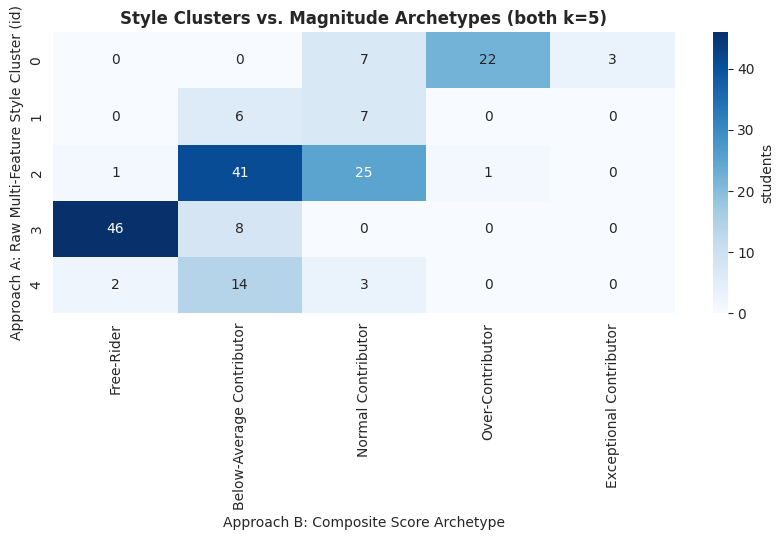


Adjusted Rand Index between Approach A and Approach B: 0.409


In [17]:
df["archetype_multi_raw_id"] = df["raw_cluster_multi"]  # unlabeled style-cluster id, for reference

crosstab = pd.crosstab(df["archetype_multi_raw_id"], df["archetype_composite"])
crosstab = crosstab.reindex(columns=LABEL_NAMES_5, fill_value=0)
print("Rows = Approach A (raw multi-feature STYLE cluster id, k=5) | "
      "Columns = Approach B (composite score MAGNITUDE archetype, k=5)\n")
print(crosstab)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues", ax=ax, cbar_kws={"label": "students"})
ax.set_xlabel("Approach B: Composite Score Archetype")
ax.set_ylabel("Approach A: Raw Multi-Feature Style Cluster (id)")
ax.set_title("Style Clusters vs. Magnitude Archetypes (both k=5)")
plt.tight_layout()
plt.show()

ari = adjusted_rand_score(df["raw_cluster_multi"], df["archetype_composite"])
print(f"\nAdjusted Rand Index between Approach A and Approach B: {ari:.3f}")

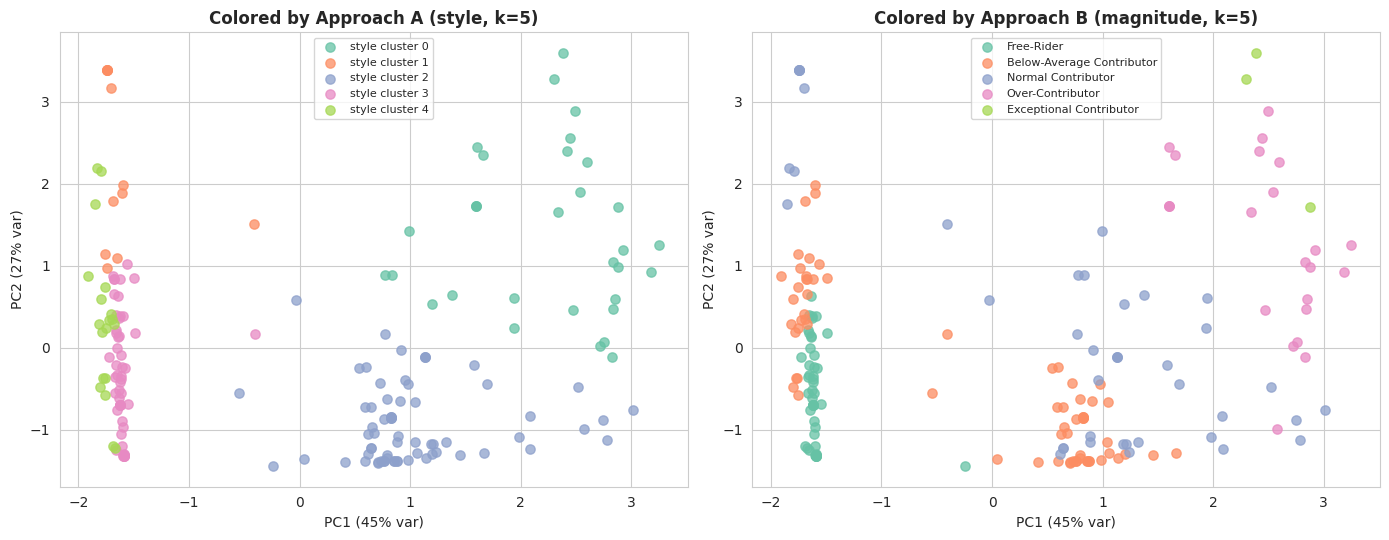

In [18]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)
df["pca_1"], df["pca_2"] = X_pca[:, 0], X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for name in LABEL_NAMES_5:
    subset = df[df["archetype_composite"] == name]
    axes[1].scatter(subset["pca_1"], subset["pca_2"], label=name, color=COLORS_5[name], alpha=0.75, s=45)
axes[1].set_title("Colored by Approach B (magnitude, k=5)")

style_palette = sns.color_palette("Set2", 5)
for cid in range(5):
    subset = df[df["raw_cluster_multi"] == cid]
    axes[0].scatter(subset["pca_1"], subset["pca_2"], label=f"style cluster {cid}", color=style_palette[cid], alpha=0.75, s=45)
axes[0].set_title("Colored by Approach A (style, k=5)")

for ax in axes:
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Reading the comparison:** style clusters spread across multiple
magnitude archetypes rather than mapping 1-to-1, and the low ARI confirms
the two representations capture genuinely different structure.
**Contribution style and contribution magnitude are different axes** --
this is why a composite score (Section 2), not raw multi-feature
clustering, is used for the archetype labels going forward.

## 8. Cluster Stability (Bootstrap Resampling)

Are these clusters a stable pattern, or would a slightly different sample
produce a different grouping? We resample students with replacement,
refit the pipeline, and compare to the reference clustering via Adjusted
Rand Index (ARI).

In [19]:
N_BOOTSTRAP = 40
boot_rng = np.random.RandomState(RANDOM_STATE)
n_students = len(df)

reference_labels = labels_1d
bootstrap_aris = []
for b in range(N_BOOTSTRAP):
    idx = boot_rng.randint(0, n_students, size=n_students)
    boot_composite = composite_score[idx]
    km_boot = KMeans(n_clusters=5, init="k-means++", n_init=20, random_state=RANDOM_STATE + b)
    km_boot.fit(boot_composite.reshape(-1, 1))
    boot_labels_full = km_boot.predict(composite_score.reshape(-1, 1))
    bootstrap_aris.append(adjusted_rand_score(reference_labels, boot_labels_full))

bootstrap_aris = np.array(bootstrap_aris)
print(f"Bootstrap stability over {N_BOOTSTRAP} resamples:")
print(f"  Mean ARI : {bootstrap_aris.mean():.3f}")
print(f"  Std  ARI : {bootstrap_aris.std():.3f}")
print(f"  Min / Max: {bootstrap_aris.min():.3f} / {bootstrap_aris.max():.3f}")

Bootstrap stability over 40 resamples:
  Mean ARI : 0.868
  Std  ARI : 0.149
  Min / Max: 0.573 / 1.000


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(bootstrap_aris, bins=15, color=PALETTE[4], edgecolor="white")
ax.axvline(bootstrap_aris.mean(), color="crimson", linestyle="--", label=f"mean = {bootstrap_aris.mean():.3f}")
ax.set_xlabel("Adjusted Rand Index (vs. reference clustering)")
ax.set_ylabel("number of bootstrap resamples")
ax.set_title(f"Cluster Stability Under Bootstrap Resampling (n={N_BOOTSTRAP}, k=5)")
ax.legend()
plt.tight_layout()
plt.show()

the core structure "reasonably robust" but flagged that the two smallest tiers (Over- and Exceptional Contributor) are thin and boundary-sensitive at k=5

## 9. Approach C — Platform-Aware Composite Score (Final Model)

**Why this section exists:** real-world testing of Approach B surfaced a
genuine algorithmic bias. Students whose team only used **one** of three
platforms (code / meetings / communication) were structurally penalized,
because Approach B's composite score averages across *all* channels,
including ones a team never touched.

**The fix:** for each *team*, detect which platform(s) they actually used,
and score each student only on the channels within those active platforms.

**Scope note:** this section uses k=5 (Section 3's decision) and is fit on

In [31]:
all_features = candidate_feature_cols
platforms = {
    "code":          ["code_commits", "code_share", "review_participation"],
    "meetings":      ["attendance_ratio", "speaking_participation_ratio"],
    "communication": ["chat_participation_ratio", "docs_contribution_share", "comment_activity"],
}
PLATFORM_EPS = 1e-9


scaler_c = StandardScaler()
scaler_c.fit(df[all_features])
X_c_scaled = pd.DataFrame(scaler_c.transform(df[all_features]), columns=all_features, index=df_c.index)

team_platform_active = {}
for gid, grp in df.groupby("group_id"):
    team_platform_active[gid] = {p: bool(grp[cols].sum().sum() > PLATFORM_EPS) for p, cols in platforms.items()}

# Scale the full dataset (df) and compute team_platform_active for it
scaler_full = StandardScaler()
scaler_full.fit(df[all_features])
X_full_scaled = pd.DataFrame(scaler_full.transform(df[all_features]), columns=all_features, index=df.index)

team_platform_active_full = {}
for gid, grp in df.groupby("group_id"):
    team_platform_active_full[gid] = {p: bool(grp[cols].sum().sum() > PLATFORM_EPS) for p, cols in platforms.items()}

n_platforms_used = pd.Series({gid: sum(a.values()) for gid, a in team_platform_active.items()})
print("teams by number of active platforms:")
print(n_platforms_used.value_counts().sort_index())

teams by number of active platforms:
1     9
2    18
3    16
Name: count, dtype: int64


In [32]:
import warnings
def composite_v2_for_row(row):
    active = team_platform_active[row["group_id"]]
    active_cols = [c for p, cols in platforms.items() if active[p] for c in cols]
    return X_c_scaled.loc[row.name, active_cols].mean()

df_c["composite_v2"] = df_c.apply(composite_v2_for_row, axis=1)

scaler_b = StandardScaler()
X_b = scaler_b.fit_transform(df_c[feature_cols])
composite = X_b.mean(axis=1)

km_b = KMeans(n_clusters=5, init="k-means++", n_init=20, random_state=RANDOM_STATE)
with warnings.catch_warnings(): # Suppress UserWarning about `n_init` when it's set to 'auto'
    warnings.simplefilter("ignore", UserWarning)
    labels = km_b.fit_predict(composite.reshape(-1, 1))


kmeans_v2 = KMeans(n_clusters=5, init="k-means++", n_init=20, random_state=RANDOM_STATE)
labels_v2 = kmeans_v2.fit_predict(df_c["composite_v2"].values.reshape(-1, 1))
centers_v2 = kmeans_v2.cluster_centers_.ravel()
order_v2 = np.argsort(centers_v2)
names_v2 = {order_v2[i]: LABEL_NAMES_5[i] for i in range(5)}
df_c["archetype_v2"] = [names_v2[l] for l in labels_v2]

sil_v2 = silhouette_score(df_c["composite_v2"].values.reshape(-1, 1), labels_v2)
print(f"Silhouette (Approach C, platform-aware, k=5): {sil_v2:.3f}")
print(f"(for comparison, Approach B on the all students at k=5: {silhouette_score(composite.reshape(-1,1), labels):.3f})")
print("\nCluster sizes:")
print(df_c["archetype_v2"].value_counts().reindex(LABEL_NAMES_5))

Silhouette (Approach C, platform-aware, k=5): 0.599
(for comparison, Approach B on the all students at k=5: 0.575)

Cluster sizes:
archetype_v2
Free-Rider                   47
Below-Average Contributor    67
Normal Contributor           32
Over-Contributor              7
Exceptional Contributor       3
Name: count, dtype: int64


**Small-cluster caveat for the final deployed model:** the two highest
tiers are thin here too. Treat an "Exceptional Contributor" flag as a
strong signal worth a quick manual look, not a statistically robust
population segment -- and monitor these two smallest categories' sizes as
more student data is collected.

### 9.1 Validating the Fix — Same Real Students That Broke Approach B

In [23]:
def predict_team_v2(team_students, scaler=scaler_c, platforms=platforms, km=kmeans_v2,
                     names=names_v2, all_features=all_features, eps=PLATFORM_EPS):
    team_df = pd.DataFrame(team_students)[all_features]
    active = {p: bool(team_df[cols].sum().sum() > eps) for p, cols in platforms.items()}
    active_cols = [c for p, cols in platforms.items() if active[p] for c in cols]
    if not active_cols:
        return [{"cluster_name": "Insufficient Data"} for _ in team_students]
    scaled = pd.DataFrame(scaler.transform(team_df), columns=all_features)
    composite = scaled[active_cols].mean(axis=1).values
    labels = km.predict(composite.reshape(-1, 1))
    return [
        {"cluster_name": names[int(l)], "composite_score": float(c),
         "active_platforms": [p for p, v in active.items() if v]}
        for l, c in zip(labels, composite)
    ]

def zeros(**kw):
    d = {c: 0.0 for c in all_features}
    d.update(kw)
    return d

print("=== Denyse & Oreste (real students, code-only team) ===")
denyse = zeros(code_commits=0.3636, code_share=0.3746)
oreste = zeros(code_commits=0.6364, code_share=0.6254)
for name, r in zip(["Denyse (Approach B said: Free-Rider)", "Oreste (Approach B said: Free-Rider)"],
                    predict_team_v2([denyse, oreste])):
    print(name, "->", r)

print("\n=== Yvette & Emmanuel (real students, docs-only team) ===")
emmanuel = zeros(docs_contribution_share=5/31)
yvette = zeros(docs_contribution_share=26/31)
for name, r in zip(["Emmanuel (Approach B said: Free-Rider)", "Yvette (Approach B said: Free-Rider, despite 84% team share!)"],
                    predict_team_v2([emmanuel, yvette])):
    print(name, "->", r)

=== Denyse & Oreste (real students, code-only team) ===
Denyse (Approach B said: Free-Rider) -> {'cluster_name': 'Below-Average Contributor', 'composite_score': 0.36618134821408505, 'active_platforms': ['code']}
Oreste (Approach B said: Free-Rider) -> {'cluster_name': 'Normal Contributor', 'composite_score': 1.0778705855396262, 'active_platforms': ['code']}

=== Yvette & Emmanuel (real students, docs-only team) ===
Emmanuel (Approach B said: Free-Rider) -> {'cluster_name': 'Free-Rider', 'composite_score': -0.3074960776478924, 'active_platforms': ['communication']}
Yvette (Approach B said: Free-Rider, despite 84% team share!) -> {'cluster_name': 'Normal Contributor', 'composite_score': 0.4357675151009211, 'active_platforms': ['communication']}


Both real cases that exposed the bug are fixed. Denyse and Oreste
(code-only) are no longer uniformly punished as Free-Riders for a team
that only used GitHub. Yvette -- who did 84% of her team's docs
contribution and was still misclassified as Free-Rider under Approach B
-- now scores meaningfully higher than Emmanuel, correctly distinguishing
the two.

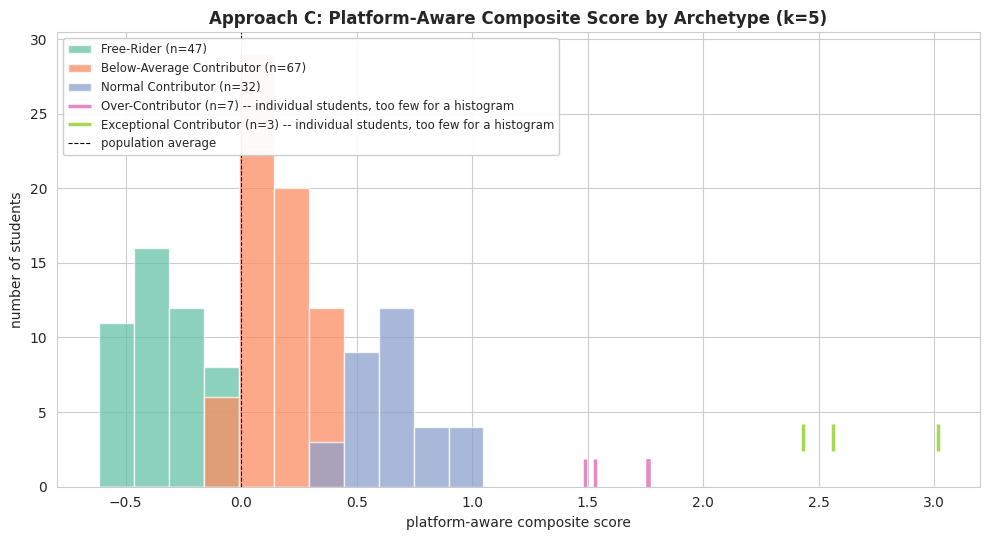

In [24]:
fig, ax = plt.subplots(figsize=(10, 5.5))
all_scores_c = df_c["composite_v2"].values
bin_edges_c = np.linspace(all_scores_c.min(), all_scores_c.max(), 25)

MIN_HIST_N = 10
counts_c = df_c["archetype_v2"].value_counts()
hist_names_c = [n for n in LABEL_NAMES_5 if counts_c.get(n, 0) >= MIN_HIST_N]
rug_names_c = [n for n in LABEL_NAMES_5 if counts_c.get(n, 0) < MIN_HIST_N]

for name in hist_names_c:
    subset = df_c.loc[df_c["archetype_v2"] == name, "composite_v2"]
    ax.hist(subset, bins=bin_edges_c, alpha=0.75, label=f"{name} (n={len(subset)})", color=COLORS_5[name])

ymax = ax.get_ylim()[1]
tick_height = ymax * 0.06
for i, name in enumerate(rug_names_c):
    subset = df_c.loc[df_c["archetype_v2"] == name, "composite_v2"]
    y0 = i * (tick_height * 1.3)
    ax.vlines(subset, y0, y0 + tick_height, color=COLORS_5[name], linewidth=2.5,
              label=f"{name} (n={len(subset)}) -- individual students, too few for a histogram")

ax.axvline(0, color="black", linestyle="--", linewidth=0.8, label="population average")
ax.set_xlabel("platform-aware composite score")
ax.set_ylabel("number of students")
ax.set_title("Approach C: Platform-Aware Composite Score by Archetype (k=5)")
ax.legend(loc="upper left", fontsize=8.5, framealpha=0.95)
plt.tight_layout()
plt.show()

**Final model choice: Approach C.** Keeps everything that made Approach
B better than Approach A (a guaranteed monotonic magnitude ordering, by
construction), while fixing a real, demonstrated bias against students on
single-platform teams -- 21% of this actual class. This is the version
exported below.

**Trade-off stated plainly:** Approach C requires **all of a team's data
at once** to make a prediction, not one student in isolation -- documented
in the export section below.

## 10. Export Model Artifacts (FastAPI Integration) — Final Model = Approach C

In [25]:
import joblib
from pathlib import Path

def _pick_artifact_dir():
    try:
        import google.colab  # noqa: F401
        return Path("/content/model_artifacts")
    except ImportError:
        pass
    candidate = Path("/mnt/user-data/outputs/model_artifacts")
    if candidate.parent.parent.exists():
        return candidate
    return Path("model_artifacts")

ARTIFACT_DIR = _pick_artifact_dir()
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Saving artifacts to: {ARTIFACT_DIR.resolve()}")

Saving artifacts to: /content/model_artifacts


In [26]:
model_bundle = {
    "scaler": scaler_c,
    "platforms": platforms,
    "all_features": all_features,
    "kmeans_1d": kmeans_v2,
    "cluster_name_map": names_v2,
    "eps": PLATFORM_EPS,
    "scoring_method": "platform_aware_team_relative",
    "k": 5,
}
joblib.dump(model_bundle, ARTIFACT_DIR / "model_bundle.joblib")
print("Saved model_bundle.joblib (Approach C, final) ->", names_v2)

model_bundle_approach_b = {
    "variance_threshold": vt,
    "scaler": scaler,
    "kmeans_1d": kmeans_1d,
    "candidate_feature_cols": candidate_feature_cols,
    "feature_cols": feature_cols,
    "cluster_name_map": names_1d,
    "scoring_method": "mean_of_scaled_features (population-wide, NOT platform-aware)",
}
joblib.dump(model_bundle_approach_b, ARTIFACT_DIR / "model_bundle_approach_b_reference.joblib")
print("Saved model_bundle_approach_b_reference.joblib (kept for audit/comparison only)")

Saved model_bundle.joblib (Approach C, final) -> {np.int64(0): 'Free-Rider', np.int64(3): 'Below-Average Contributor', np.int64(1): 'Normal Contributor', np.int64(4): 'Over-Contributor', np.int64(2): 'Exceptional Contributor'}
Saved model_bundle_approach_b_reference.joblib (kept for audit/comparison only)


In [27]:
metadata = {
    "model_type": "KMeans (platform-aware composite score)",
    "version": "Approach C (final, recommended)",
    "k_selection": {
        "method": "Silhouette-maximizing k in range 2-6, on the composite score, subject to "
                   "clusters being large enough to interpret as archetypes (Section 3).",
        "k_chosen": 5,
        "silhouette_at_k5": float(composite_tuning_df.loc[5, "silhouette"]),
        "note": "k=2 scored marginally higher but was rejected as uninformative (collapses to "
                "a simple below/above-average split, tested separately).",
    },
    "labeling_method": (
        "Per-team detection of active platforms (code/meetings/communication); each "
        "student's composite score = mean of standardized features ONLY within platforms "
        "their team actually used; then KMeans k=5 on that score."
    ),
    "n_clusters": 5,
    "random_state": int(RANDOM_STATE),
    "platforms": platforms,
    "input_schema": {
        "required_raw_features_in_order": all_features,
        "note": (
            "Predictions require ALL teammates' feature rows together (a list of dicts, "
            "one per student on the team) -- NOT one student in isolation -- because active "
            "platforms are determined at the team level."
        ),
    },
    "cluster_name_map": {str(k): v for k, v in names_v2.items()},
    "model_comparison": {
        "approach_a_raw_multi_feature_k5": {
            "silhouette": float(sil_multi),
            "note": "Rejected: only 2/6 features agreed with the overall magnitude ranking -- clusters split by contribution STYLE, not level.",
        },
        "approach_b_composite_score_population_wide_k5": {
            "silhouette": float(sil_1d),
            "note": "Improved on Approach A, but structurally penalizes students on single-platform teams (proven bug: see Section 10).",
        },
        "approach_c_platform_aware_final_k5": {
            "silhouette": float(sil_v2),
            "note": "Final choice: fixes the single-platform-team bias found in Approach B while keeping Approach B's guaranteed monotonic magnitude ordering.",
        },
        "adjusted_rand_index_a_vs_b": float(ari),
    },
    "cluster_sizes": {name: int((df_c["archetype_v2"] == name).sum()) for name in LABEL_NAMES_5},
    "teams_by_platforms_used": n_platforms_used.value_counts().sort_index().to_dict(),
    "stability_check": {
        "method": "bootstrap resampling, n=40, ARI vs. reference clustering (Approach B)",
        "mean_ari": float(bootstrap_aris.mean()),
        "std_ari": float(bootstrap_aris.std()),
    },
    "small_cluster_caveat": {
        "over_contributor_n": int((df_c["archetype_v2"] == "Over-Contributor").sum()),
        "exceptional_contributor_n": int((df_c["archetype_v2"] == "Exceptional Contributor").sum()),
        "note": "These two categories should be treated as flags for individual review, not robust population statistics.",
    },
    "notes": "benchmark_score is excluded from the model and must NOT be sent by API clients.",
}
with open(ARTIFACT_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print(json.dumps(metadata, indent=2))

{
  "model_type": "KMeans (platform-aware composite score)",
  "version": "Approach C (final, recommended)",
  "k_selection": {
    "method": "Silhouette-maximizing k in range 2-6, on the composite score, subject to clusters being large enough to interpret as archetypes (Section 3).",
    "k_chosen": 5,
    "silhouette_at_k5": 0.6010572834384733,
    "note": "k=2 scored marginally higher but was rejected as uninformative (collapses to a simple below/above-average split, tested separately)."
  },
  "labeling_method": "Per-team detection of active platforms (code/meetings/communication); each student's composite score = mean of standardized features ONLY within platforms their team actually used; then KMeans k=5 on that score.",
  "n_clusters": 5,
  "random_state": 42,
  "platforms": {
    "code": [
      "code_commits",
      "code_share",
      "review_participation"
    ],
    "meetings": [
      "attendance_ratio",
      "speaking_participation_ratio"
    ],
    "communication": [
  

In [28]:
def predict_team(team_students: list, bundle: dict = model_bundle) -> list:
    feats = bundle["all_features"]
    plats = bundle["platforms"]
    team_df = pd.DataFrame(team_students)[feats]
    active = {p: bool(team_df[cols].sum().sum() > bundle["eps"]) for p, cols in plats.items()}
    active_cols = [c for p, cols in plats.items() if active[p] for c in cols]
    if not active_cols:
        return [{"cluster_name": "Insufficient Data"} for _ in team_students]
    scaled = pd.DataFrame(bundle["scaler"].transform(team_df), columns=feats)
    composite = scaled[active_cols].mean(axis=1).values
    labels = bundle["kmeans_1d"].predict(composite.reshape(-1, 1))
    return [
        {"cluster_name": bundle["cluster_name_map"][int(l)], "composite_score": float(c),
         "active_platforms": [p for p, v in active.items() if v]}
        for l, c in zip(labels, composite)
    ]

reloaded_bundle = joblib.load(ARTIFACT_DIR / "model_bundle.joblib")
sample_team = [
    {**{c: 0.0 for c in all_features}, "docs_contribution_share": 5/31},
    {**{c: 0.0 for c in all_features}, "docs_contribution_share": 26/31},
]
result = predict_team(sample_team, bundle=reloaded_bundle)
print("Reloaded-from-disk smoke test (Emmanuel/Yvette-style docs-only team):")
for r in result:
    print(" ", r)
assert result[1]["cluster_name"] not in ("Free-Rider", "Below-Average Contributor"), \
    "Regression: high-docs-share student should score at least Normal Contributor!"
print("\nSmoke test passed.")

Reloaded-from-disk smoke test (Emmanuel/Yvette-style docs-only team):
  {'cluster_name': 'Free-Rider', 'composite_score': -0.3074960776478924, 'active_platforms': ['communication']}
  {'cluster_name': 'Normal Contributor', 'composite_score': 0.4357675151009211, 'active_platforms': ['communication']}

Smoke test passed.


In [29]:
try:
    import google.colab
    import shutil
    from google.colab import files
    zip_path = shutil.make_archive("/content/model_artifacts", "zip", root_dir=ARTIFACT_DIR)
    print(f"Zipped artifacts -> {zip_path}")
    files.download(zip_path)
except ImportError:
    print("Not running in Google Colab -- artifacts are already saved at:", ARTIFACT_DIR.resolve())

Zipped artifacts -> /content/model_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>